<a href="https://colab.research.google.com/github/lee-edgar/study/blob/main/%EB%82%98%EB%8F%99%EB%B9%88resnet_%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#### ResNet18 모델 정의 및 인스턴스 초기화


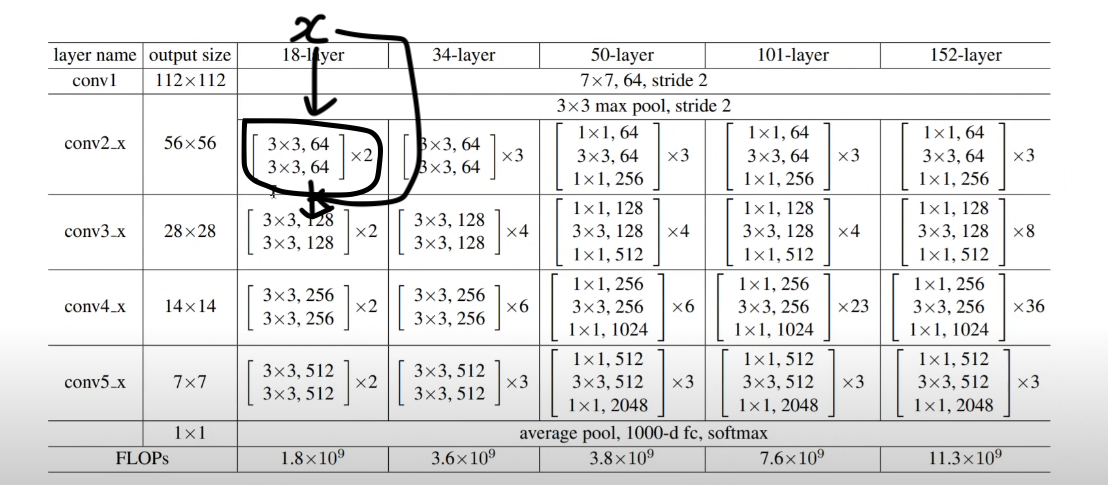


위 이미지의 검은색 표기부분은 아래 BasicBlock class를 의미합니다.
해당 BasicBlock을 연속적으로 여러개를 쌓아서 코드를 구현해나갑니다.

BasicBlock은 하나의 [3x3,64 layer + BatchNorm + ReLU]를 2개로 쌓는 컨볼루션 레이어로 구성됩니다.

입력 x에서identity mapping을 이용해 2번째 컨볼루션에 결과에 추가하고 이후에 relu가 씌워진 뒤 2번째 BasicBlock으로 연결되는 과정을 볼 수 있음

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import os


# ResNet18을 위해 최대한 간단히 수정한 BasicBlock 클래스 정의
class BasicBlock(nn.Module):
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()

        # 3x3 필터를 사용 (너비와 높이를 줄일 때는 stride 값 조절)
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes) # 배치 정규화(batch normalization)

        # 3x3 필터를 사용 (패딩을 1만큼 주기 때문에 너비와 높이가 동일)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes) # 배치 정규화(batch normalization)

        self.shortcut = nn.Sequential() # identity인 경우
        if stride != 1: # stride가 1이 아니라면, 입력값과 출력값의 demension이 다르기 때문에 demension을 맞춰주기 위해서
        #stride를 동일하게 차원을 맞춰주어 입력x가 연결되도록 함.  Identity mapping이 아닌 경우
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes)
            )

    def forward(self, x):
        # 첫 번째 conv -> batchnorm -> relu -> 두 번째 conv -> batchnorm -> skip connection -> relu
        # 모든 conv는 3x3 filter를 사용하고, 2개의 kernel을 통함.
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x) # (핵심) skip connection
        out = F.relu(out)
        return out


# ResNet 클래스 정의
class ResNet(nn.Module):
    # 맨 위 이미지와 동일하게 18-layer를 아래와 같이 구현한 모습을 볼 수 있음(=64, 128, 256, 512)

    def __init__(self, block, num_blocks, num_classes=10):
        # num_block은 18-layer에서 2번씩 중첩되기 사용하는 모습을 볼 수 있음 = 아래 def ResNet18에서 [2,2,2,2]로 선택 된 모습
        super(ResNet, self).__init__()
        self.in_planes = 64

        # 64개의 3x3 필터(filter)를 사용
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.linear = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        # 해당 함수로 basicBlock이 연속적으로 생성하는 기능 수행
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes # 다음 레이어를 위해 채널 수 변경
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out


# ResNet18 함수 정의
def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

# _maker_layer의          strides = [stride] + [1] * (num_blocks - 1) 코드의 부가 설명

def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])
위 코드에 의해서 BasicBlock에는 2값이 들어오고, 아래 식에 녹이면.
```
[stride] + ([i] * (num_blocks -1 ))
self.layer1에서 stride가 1 = [1, 1]  == [1] + ([1] * (2 -1 ))
self.layer2에서 stride가 2 = [2, 1] == [2] + ([1] * (2 -1 ))
self.layer3에서 stride가 2 = [2, 1] == [2] + ([1] * (2 -1 ))
self.layer4에서 stride가 2 = [2, 1] == [2] + ([1] * (2 -1 ))
```

| Layer  | stride 인자 | strides 리스트 | 크기 변화 예 (HxW)         |
| ------ | --------- | ----------- | --------------------- |
| layer1 | 1         | `[1, 1]`    | 32×32 → 32×32         |
| layer2 | 2         | `[2, 1]`    | 32×32 → 16×16 |
| layer3 | 2         | `[2, 1]`    | 16×16 → 8×8|
| layer4 | 2         | `[2, 1]`    | 8×8 → 4×4|

layer의 입력과 출력의 중첩이 연결되어 있기에, 32x32에서 4x4까지 크기의 변화가 생기게 되는 것임

왜 첫 layer는 stride=1?
-> 처음에는 feature map크기를 줄이지 않기 위해서
* 처음부터 이미지가 작아지면 정보 손실이 발생하게이 처음 블럭에서는 유지시키고, 이후 블럭들부터 차츰차츰 줄이면서 중요한 특징을 추출해 나가는 구조를 만들어야 하기 때문임.



In [ ]:
import torchvision
import torchvision.transforms as transforms

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # CIFAR10의 일반적인 padding값은 4, 크기는 32
    transforms.RandomHorizontalFlip(), # DadaAugmentation
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=4)

In [ ]:
device = 'cuda'

net = ResNet18()
net = net.to(device)
net = torch.nn.DataParallel(net)
cudnn.benchmark = True

learning_rate = 0.1 # CIFAR10의 통상적인 값은 0.1 -> 0.01 -> 0.001로 줄여나가면서 진행
file_name = 'resnet18_cifar10.pt' # model saved name

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9, weight_decay=0.0002)


def train(epoch):
    print('\n[ Train epoch: %d ]' % epoch)
    net.train()
    train_loss = 0
    correct = 0
    total = 0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        benign_outputs = net(inputs)
        loss = criterion(benign_outputs, targets)
        loss.backward()

        optimizer.step()
        train_loss += loss.item()
        _, predicted = benign_outputs.max(1)

        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        if batch_idx % 100 == 0:
            print('\nCurrent batch:', str(batch_idx))
            print('Current benign train accuracy:', str(predicted.eq(targets).sum().item() / targets.size(0)))
            print('Current benign train loss:', loss.item())

    print('\nTotal benign train accuarcy:', 100. * correct / total)
    print('Total benign train loss:', train_loss)


def test(epoch):
    print('\n[ Test epoch: %d ]' % epoch)
    net.eval()
    loss = 0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(test_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        total += targets.size(0)

        outputs = net(inputs) # parameter 업데이트 없이 단순히 입력에 대한 아웃풋 뽑기.
        loss += criterion(outputs, targets).item()

        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()

    print('\nTest accuarcy:', 100. * correct / total)
    print('Test average loss:', loss / total)

    state = {
        'net': net.state_dict()
    }
    if not os.path.isdir('checkpoint'):
        os.mkdir('checkpoint')
    torch.save(state, './checkpoint/' + file_name)
    print('Model Saved!')


def adjust_learning_rate(optimizer, epoch):
    # 학습을 위한 테크닉. learning-rate를 단계적으로 변경.
    # 200번 학습시 100번, 150번째에 10분에 1로 lr 변경 하여 optimizer 향상.
    lr = learning_rate
    if epoch >= 100:
        lr /= 10
    if epoch >= 150:
        lr /= 10
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

#### 학습(Training) 진행

대략 20번의 epoch 이후에도 85%가량의 test accuracy를 얻을 수 있습니다.

In [ ]:
# for epoch in range(0, 200):
for epoch in range(0, 20):
    adjust_learning_rate(optimizer, epoch)
    train(epoch)
    test(epoch)

[ Train epoch: 0 ]

Current batch: 0
Current benign train accuracy: 0.078125
Current benign train loss: 2.342548370361328

Current batch: 100
Current benign train accuracy: 0.234375
Current benign train loss: 1.9885613918304443

Current batch: 200
Current benign train accuracy: 0.3984375
Current benign train loss: 1.592935562133789

Current batch: 300
Current benign train accuracy: 0.375
Current benign train loss: 1.6573998928070068

Total benign train accuarcy: 32.606
Total benign train loss: 728.0853297710419

[ Test epoch: 0 ]

Test accuarcy: 32.37
Test average loss: 0.019251463556289674
Model Saved!

[ Train epoch: 1 ]

Current batch: 0
Current benign train accuracy: 0.4765625
Current benign train loss: 1.467000961303711

Current batch: 100
Current benign train accuracy: 0.4609375
Current benign train loss: 1.41520094871521

Current batch: 200
Current benign train accuracy: 0.4765625
Current benign train loss: 1.416500210762024

Current batch: 300
Current benign train accuracy: 0.5390625
Current benign train loss: 1.2315757274627686

Total benign train accuarcy: 49.85
Total benign train loss: 533.2066541910172

[ Test epoch: 1 ]

Test accuarcy: 45.72
Test average loss: 0.015757604146003724
Model Saved!

[ Train epoch: 2 ]

Current batch: 0
Current benign train accuracy: 0.6484375
Current benign train loss: 1.0243165493011475

Current batch: 100
Current benign train accuracy: 0.5703125
Current benign train loss: 1.1561983823776245

Current batch: 200
Current benign train accuracy: 0.6328125
Current benign train loss: 1.0709519386291504

Current batch: 300
Current benign train accuracy: 0.6328125
Current benign train loss: 1.077557921409607

Total benign train accuarcy: 60.638
Total benign train loss: 429.05279356241226

[ Test epoch: 2 ]

Test accuarcy: 55.7
Test average loss: 0.012377450782060623
Model Saved!

[ Train epoch: 3 ]

Current batch: 0
Current benign train accuracy: 0.5859375
Current benign train loss: 1.0553513765335083

Current batch: 100
Current benign train accuracy: 0.7109375
Current benign train loss: 0.8117691874504089

Current batch: 200
Current benign train accuracy: 0.734375
Current benign train loss: 0.782296895980835

Current batch: 300
Current benign train accuracy: 0.7265625
Current benign train loss: 0.8579391837120056

Total benign train accuarcy: 66.628
Total benign train loss: 368.8282547593117

[ Test epoch: 3 ]

Test accuarcy: 62.94
Test average loss: 0.011110778278112412
Model Saved!

[ Train epoch: 4 ]

Current batch: 0
Current benign train accuracy: 0.6953125
Current benign train loss: 0.8858131170272827

Current batch: 100
Current benign train accuracy: 0.671875
Current benign train loss: 0.869682788848877

Current batch: 200
Current benign train accuracy: 0.734375
Current benign train loss: 0.8007809519767761

Current batch: 300
Current benign train accuracy: 0.6953125
Current benign train loss: 0.8192347288131714

Total benign train accuarcy: 70.534
Total benign train loss: 325.6062932610512

[ Test epoch: 4 ]

Test accuarcy: 68.61
Test average loss: 0.009179449623823166
Model Saved!

[ Train epoch: 5 ]

Current batch: 0
Current benign train accuracy: 0.7109375
Current benign train loss: 0.7147080898284912

Current batch: 100
Current benign train accuracy: 0.7265625
Current benign train loss: 0.7322123050689697

Current batch: 200
Current benign train accuracy: 0.7421875
Current benign train loss: 0.7949008345603943

Current batch: 300
Current benign train accuracy: 0.8046875
Current benign train loss: 0.622573971748352

Total benign train accuarcy: 74.776
Total benign train loss: 283.41117030382156

[ Test epoch: 5 ]

Test accuarcy: 66.08
Test average loss: 0.010336347603797912
Model Saved!

[ Train epoch: 6 ]

Current batch: 0
Current benign train accuracy: 0.7890625
Current benign train loss: 0.6463558673858643

Current batch: 100
Current benign train accuracy: 0.7421875
Current benign train loss: 0.7392880916595459

Current batch: 200
Current benign train accuracy: 0.71875
Current benign train loss: 0.747829794883728

Current batch: 300
Current benign train accuracy: 0.8046875
Current benign train loss: 0.541568398475647

Total benign train accuarcy: 78.13
Total benign train loss: 246.6013989150524

[ Test epoch: 6 ]

Test accuarcy: 79.19
Test average loss: 0.006162648651003837
Model Saved!

[ Train epoch: 7 ]

Current batch: 0
Current benign train accuracy: 0.8359375
Current benign train loss: 0.4995025396347046

Current batch: 100
Current benign train accuracy: 0.8203125
Current benign train loss: 0.5459635853767395

Current batch: 200
Current benign train accuracy: 0.7421875
Current benign train loss: 0.7259557843208313

Current batch: 300
Current benign train accuracy: 0.8203125
Current benign train loss: 0.5176252126693726

Total benign train accuarcy: 80.286
Total benign train loss: 221.22545537352562

[ Test epoch: 7 ]

Test accuarcy: 79.12
Test average loss: 0.005947562873363495
Model Saved!

[ Train epoch: 8 ]

Current batch: 0
Current benign train accuracy: 0.8203125
Current benign train loss: 0.4396432638168335

Current batch: 100
Current benign train accuracy: 0.8125
Current benign train loss: 0.5141220092773438

Current batch: 200
Current benign train accuracy: 0.8203125
Current benign train loss: 0.510535478591919

Current batch: 300
Current benign train accuracy: 0.828125
Current benign train loss: 0.5050277709960938

Total benign train accuarcy: 82.262
Total benign train loss: 199.77128410339355

[ Test epoch: 8 ]

Test accuarcy: 75.92
Test average loss: 0.007395538124442101
Model Saved!

[ Train epoch: 9 ]

Current batch: 0
Current benign train accuracy: 0.859375
Current benign train loss: 0.36461132764816284

Current batch: 100
Current benign train accuracy: 0.859375
Current benign train loss: 0.4459194242954254

Current batch: 200
Current benign train accuracy: 0.8203125
Current benign train loss: 0.4709767997264862

Current batch: 300
Current benign train accuracy: 0.90625
Current benign train loss: 0.32980111241340637

Total benign train accuarcy: 83.904
Total benign train loss: 184.7817738056183

[ Test epoch: 9 ]

Test accuarcy: 80.95
Test average loss: 0.0058574866235256194
Model Saved!

[ Train epoch: 10 ]

Current batch: 0
Current benign train accuracy: 0.828125
Current benign train loss: 0.4373864531517029

Current batch: 100
Current benign train accuracy: 0.8671875
Current benign train loss: 0.3559974431991577

Current batch: 200
Current benign train accuracy: 0.8203125
Current benign train loss: 0.48067837953567505

Current batch: 300
Current benign train accuracy: 0.875
Current benign train loss: 0.3984924554824829

Total benign train accuarcy: 84.892
Total benign train loss: 171.66229909658432

[ Test epoch: 10 ]

Test accuarcy: 82.99
Test average loss: 0.005103023992478847
Model Saved!

[ Train epoch: 11 ]

Current batch: 0
Current benign train accuracy: 0.875
Current benign train loss: 0.3510317802429199

Current batch: 100
Current benign train accuracy: 0.875
Current benign train loss: 0.32915860414505005

Current batch: 200
Current benign train accuracy: 0.921875
Current benign train loss: 0.3297663927078247

Current batch: 300
Current benign train accuracy: 0.8828125
Current benign train loss: 0.34490451216697693

Total benign train accuarcy: 86.196
Total benign train loss: 156.00640574097633

[ Test epoch: 11 ]

Test accuarcy: 83.43
Test average loss: 0.005025931619107723
Model Saved!

[ Train epoch: 12 ]

Current batch: 0
Current benign train accuracy: 0.8984375
Current benign train loss: 0.316066712141037

Current batch: 100
Current benign train accuracy: 0.828125
Current benign train loss: 0.4465980529785156

Current batch: 200
Current benign train accuracy: 0.875
Current benign train loss: 0.3925016522407532

Current batch: 300
Current benign train accuracy: 0.8125
Current benign train loss: 0.5082284808158875

Total benign train accuarcy: 86.922
Total benign train loss: 147.18924406170845

[ Test epoch: 12 ]

Test accuarcy: 81.88
Test average loss: 0.0055881109565496445
Model Saved!

[ Train epoch: 13 ]

Current batch: 0
Current benign train accuracy: 0.8828125
Current benign train loss: 0.344944030046463

Current batch: 100
Current benign train accuracy: 0.8828125
Current benign train loss: 0.29982665181159973

Current batch: 200
Current benign train accuracy: 0.9140625
Current benign train loss: 0.26996269822120667

Current batch: 300
Current benign train accuracy: 0.8828125
Current benign train loss: 0.32363879680633545

Total benign train accuarcy: 87.74
Total benign train loss: 138.93322916328907

[ Test epoch: 13 ]

Test accuarcy: 84.9
Test average loss: 0.004571232542395592
Model Saved!

[ Train epoch: 14 ]

Current batch: 0
Current benign train accuracy: 0.921875
Current benign train loss: 0.22633010149002075

Current batch: 100
Current benign train accuracy: 0.90625
Current benign train loss: 0.2942282557487488

Current batch: 200
Current benign train accuracy: 0.90625
Current benign train loss: 0.2622967064380646

Current batch: 300
Current benign train accuracy: 0.859375
Current benign train loss: 0.35620009899139404

Total benign train accuarcy: 88.148
Total benign train loss: 133.99209225177765

[ Test epoch: 14 ]

Test accuarcy: 83.2
Test average loss: 0.004986019828915596
Model Saved!

[ Train epoch: 15 ]

Current batch: 0
Current benign train accuracy: 0.8671875
Current benign train loss: 0.3578110337257385

Current batch: 100
Current benign train accuracy: 0.859375
Current benign train loss: 0.44672730565071106

Current batch: 200
Current benign train accuracy: 0.90625
Current benign train loss: 0.3109784722328186

Current batch: 300
Current benign train accuracy: 0.890625
Current benign train loss: 0.321890652179718

Total benign train accuarcy: 88.54
Total benign train loss: 129.44860856235027

[ Test epoch: 15 ]

Test accuarcy: 83.95
Test average loss: 0.00497876156270504
Model Saved!

[ Train epoch: 16 ]

Current batch: 0
Current benign train accuracy: 0.9296875
Current benign train loss: 0.22490273416042328

Current batch: 100
Current benign train accuracy: 0.8984375
Current benign train loss: 0.23266059160232544

Current batch: 200
Current benign train accuracy: 0.8671875
Current benign train loss: 0.46236950159072876

Current batch: 300
Current benign train accuracy: 0.8671875
Current benign train loss: 0.36238518357276917

Total benign train accuarcy: 89.232
Total benign train loss: 121.14673912525177

[ Test epoch: 16 ]

Test accuarcy: 84.81
Test average loss: 0.00471608787626028
Model Saved!

[ Train epoch: 17 ]

Current batch: 0
Current benign train accuracy: 0.8984375
Current benign train loss: 0.3090561628341675

Current batch: 100
Current benign train accuracy: 0.90625
Current benign train loss: 0.28426840901374817

Current batch: 200
Current benign train accuracy: 0.9140625
Current benign train loss: 0.261736661195755

Current batch: 300
Current benign train accuracy: 0.890625
Current benign train loss: 0.2979798913002014

Total benign train accuarcy: 89.666
Total benign train loss: 117.36104936897755

[ Test epoch: 17 ]

Test accuarcy: 79.67
Test average loss: 0.006324853277206421
Model Saved!

[ Train epoch: 18 ]

Current batch: 0
Current benign train accuracy: 0.9296875
Current benign train loss: 0.20375630259513855

Current batch: 100
Current benign train accuracy: 0.921875
Current benign train loss: 0.3001909852027893

Current batch: 200
Current benign train accuracy: 0.875
Current benign train loss: 0.253219336271286

Current batch: 300
Current benign train accuracy: 0.9140625
Current benign train loss: 0.2335602045059204

Total benign train accuarcy: 89.984
Total benign train loss: 113.86838936805725

[ Test epoch: 18 ]

Test accuarcy: 83.34
Test average loss: 0.00514583497941494
Model Saved!

[ Train epoch: 19 ]

Current batch: 0
Current benign train accuracy: 0.8984375
Current benign train loss: 0.36447006464004517

Current batch: 100
Current benign train accuracy: 0.8828125
Current benign train loss: 0.3062523901462555

Current batch: 200
Current benign train accuracy: 0.8828125
Current benign train loss: 0.3175150454044342

Current batch: 300
Current benign train accuracy: 0.9296875
Current benign train loss: 0.19365999102592468

Total benign train accuarcy: 90.082
Total benign train loss: 111.900165989995

[ Test epoch: 19 ]

Test accuarcy: 86.42
Test average loss: 0.004216953121125698
Model Saved!